In [4]:
# 1. IMPORT LIBRARY
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [5]:
# 2. DATA UNDERSTANDING
df = pd.read_csv("crop_yield.csv")

print("===== DATA AWAL =====")
print (df.head())

print("===== INFO DATA =====")
(df.info())

print("===== STATISTIK DESKRIPTIF =====")
(df.describe())

===== DATA AWAL =====
           crop  year       season  state     area  production  fertilizer  \
0      Arecanut  1997  Whole Year   Assam  73814.0       56708  7024878.38   
1     Arhar/Tur  1997  Kharif       Assam   6637.0        4685   631643.29   
2   Castor seed  1997  Kharif       Assam    796.0          22    75755.32   
3      Coconut   1997  Whole Year   Assam  19656.0   126905000  1870661.52   
4  Cotton(lint)  1997  Kharif       Assam   1739.0         794   165500.63   

   pesticide        yield  
0   22882.34     0.796087  
1    2057.47     0.710435  
2     246.76     0.238333  
3    6093.36  5238.051739  
4     539.09     0.420909  
===== INFO DATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   crop        19689 non-null  object 
 1   year        19689 non-null  int64  
 2   season      19689 non-null  object 
 3   s

,year,area,production,fertilizer,pesticide,yield
count,19689.000000,1.968900e+04,1.968900e+04,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,4.835407e+09,1.575051e+07,21105.000000


In [6]:
# 3. DATA PREPROCESSING
print("\nMissing Value:", df.isnull().sum().sum())
df = df.dropna()

print("Data Duplikat:", df.duplicated().sum())
df = df.drop_duplicates()

cat_cols = ['crop', 'season', 'state']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
print("===== SETELAH ENCODING =====")
print (df[cat_cols].head())

Q1 = df['yield'].quantile(0.25)
Q3 = df['yield'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['yield'] >= Q1 - 1.5 * IQR) & 
        (df['yield'] <= Q3 + 1.5 * IQR)]


X = df.drop(columns=['yield'])
y = df['yield']
print("===== DATA FEATURE (X) =====")
print (X.head())
print("\n===== DATA TARGET (y) =====")
print (y.head())

scaler = StandardScaler()
X = scaler.fit_transform(X)


Missing Value: 0
Data Duplikat: 0
===== SETELAH ENCODING =====
   crop  season  state
0     0       4      2
1     1       1      2
2     8       1      2
3     9       4      2
4    11       1      2
===== DATA FEATURE (X) =====
   crop  year  season  state     area  production  fertilizer  pesticide
0     0  1997       4      2  73814.0       56708  7024878.38   22882.34
1     1  1997       1      2   6637.0        4685   631643.29    2057.47
2     8  1997       1      2    796.0          22    75755.32     246.76
4    11  1997       1      2   1739.0         794   165500.63     539.09
5    13  1997       4      2  13587.0        9073  1293074.79    4211.97

===== DATA TARGET (y) =====
0    0.796087
1    0.710435
2    0.238333
4    0.420909
5    0.643636
Name: yield, dtype: float64


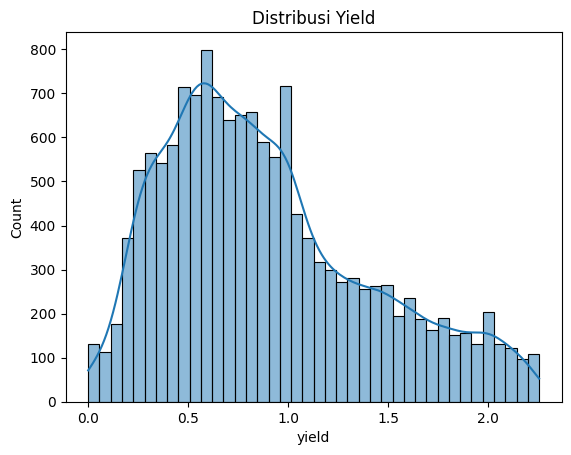

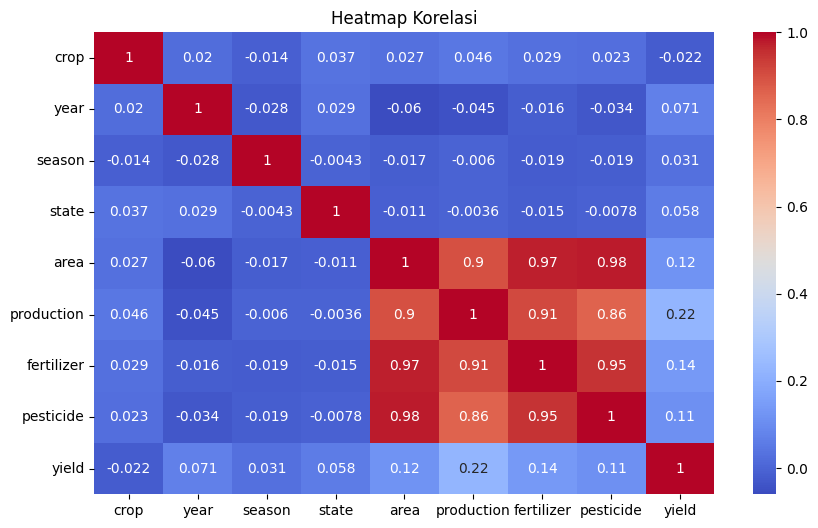

In [22]:
# 4. EDA (VISUALISASI)
# Distribusi
sns.histplot(y, kde=True)
plt.title("Distribusi Yield")
plt.show()

# Korelasi
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi")
plt.show()

In [39]:
# 5. DATA SPLITTING (3 VARIASI)
splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

final_results = []

for split_name, test_size in splits.items():
    print(f"\n===== SPLIT {split_name} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Random Forest
    rf_params = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    rf_grid = GridSearchCV(RandomForestRegressor(random_state=42),
                           rf_params, cv=3, n_jobs=-1)
    rf_grid.fit(X_train, y_train)
    rf_best = rf_grid.best_estimator_

    # Gradient Boosting
    gbr_params = {
        'n_estimators': [100, 150],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 4]
    }

    gbr_grid = GridSearchCV(GradientBoostingRegressor(random_state=42),
                            gbr_params, cv=3, n_jobs=-1)
    gbr_grid.fit(X_train, y_train)
    gbr_best = gbr_grid.best_estimator_

    # XGBoost
    xgb_params = {
        'n_estimators': [100, 150],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 4]
    }

    xgb_grid = GridSearchCV(XGBRegressor(random_state=42),
                            xgb_params, cv=3, n_jobs=-1)
    xgb_grid.fit(X_train, y_train)
    xgb_best = xgb_grid.best_estimator_

    # 7. Evaluasi
    def evaluate(model, name):
        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        final_results.append([split_name, name, mae, mse, rmse, r2])

    evaluate(rf_best, "Random Forest")
    evaluate(gbr_best, "Gradient Boosting")
    evaluate(xgb_best, "XGBoost")



===== SPLIT 70:30 =====

===== SPLIT 80:20 =====

===== SPLIT 90:10 =====



===== HASIL AKHIR SEMUA MODEL =====
   Split              Model       MAE       MSE      RMSE  R2 Score
0  70:30      Random Forest  0.086951  0.019718  0.140419  0.926663
3  80:20      Random Forest  0.085999  0.019909  0.141099  0.926311
6  90:10      Random Forest  0.085657  0.021841  0.147786  0.920089
4  80:20  Gradient Boosting  0.109766  0.025590  0.159969  0.905282
7  90:10  Gradient Boosting  0.108396  0.026609  0.163124  0.902641
2  70:30            XGBoost  0.111587  0.026497  0.162779  0.901448
1  70:30  Gradient Boosting  0.112678  0.026748  0.163548  0.900514
5  80:20            XGBoost  0.111459  0.026887  0.163972  0.900483
8  90:10            XGBoost  0.111204  0.028282  0.168171  0.896523


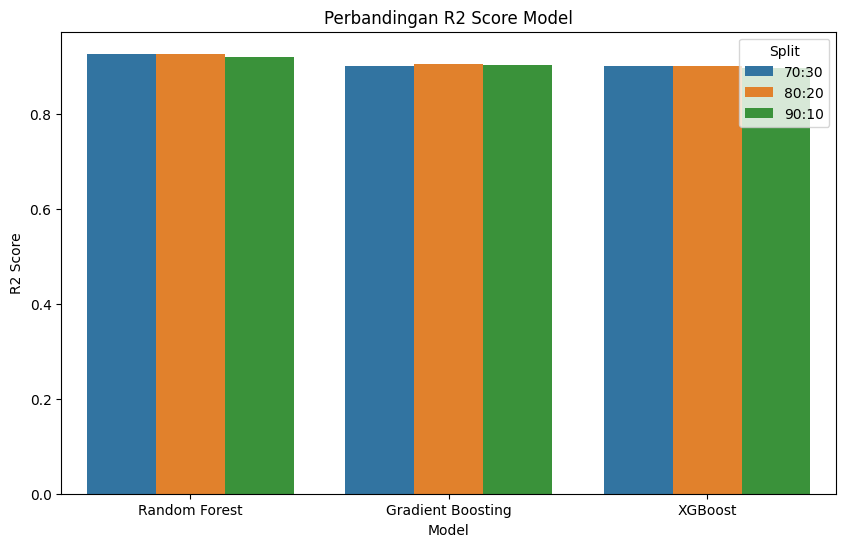

In [40]:
# 9. HASIL AKHIR
results_df = pd.DataFrame(final_results, columns=[
    "Split", "Model", "MAE", "MSE", "RMSE", "R2 Score"
])

print("\n===== HASIL AKHIR SEMUA MODEL =====")
print(results_df.sort_values(by="R2 Score", ascending=False))

# 10. VISUALISASI PERBANDINGAN
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="Model", y="R2 Score", hue="Split")
plt.title("Perbandingan R2 Score Model")
plt.show()

In [ ]:
# ======================
# INFERENCE (PREDIKSI DATA BARU)
# ======================

best_model = rf_best  

# data baru
new_data = pd.DataFrame({
    'crop': [0],
    'year': [2022],
    'season': [1],
    'state': [2],
    'area': [4500],
    'production': [15000],
    'fertilizer': [250000],
    'pesticide': [800]
})

print("=== Data Input ===")
display(new_data)

# scaling
new_data_scaled = scaler.transform(new_data)

# prediksi
prediction = best_model.predict(new_data_scaled)

print("\n=== HASIL PREDIKSI ===")
print("Prediksi Yield:", prediction[0])

=== Data Input ===


,crop,year,season,state,area,production,fertilizer,pesticide
0,0,2022,1,2,4500,15000,250000,800



=== HASIL PREDIKSI ===
Prediksi Yield: 1.9024750367
